In [2]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn

In [5]:
import pandas as pd
import numpy as np



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\HARSHA
[nltk_data]     VARDHINI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
import os

print(os.path.isfile("Resume.csv"))
print(os.path.isdir("Resume.csv"))

False
True


In [11]:
import os

print(os.listdir())

['data', 'Resume.csv', 'Resume_Screening.ipynb']


In [12]:
df = pd.read_csv("Resume.csv/Resume.csv")

In [13]:
print(df.shape)

(2484, 4)


In [14]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [15]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [16]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_resume(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = ' '.join(word for word in text.split()
                    if word not in stop_words)
    return text

df['clean_resume'] = df['Resume_str'].apply(clean_resume)

df[['clean_resume']].head()

,clean_resume
0,hr administrator marketing associate hr admini...
1,hr specialist us hr operations summary versati...
2,hr director summary years experience recruitin...
3,hr specialist summary dedicated driven dynamic...
4,hr manager skill highlights hr skills hr depar...


In [17]:
job_description = """
Python
Machine Learning
Data Science
SQL
Data Analysis
Pandas
NumPy
Scikit Learn
Deep Learning
Communication Skills
"""

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = df['clean_resume'].tolist()
documents.append(job_description)

tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(documents)

print(tfidf_matrix.shape)

(2485, 5000)


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf_matrix[-1]

resume_vectors = tfidf_matrix[:-1]

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

df['Similarity_Score'] = similarity_scores

df.head()

,ID,Resume_str,Resume_html,Category,clean_resume,Similarity_Score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,0.021242
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,0.012506
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...,0.003650
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...,0.008045
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,0.006160


In [20]:
top_candidates = df.sort_values(
    by='Similarity_Score',
    ascending=False
)

top_candidates[
    ['Category','Similarity_Score']
].head(10)

,Category,Similarity_Score
1762,ENGINEERING,0.306342
1218,CONSULTANT,0.276646
2153,BANKING,0.252884
1142,CONSULTANT,0.223754
929,AGRICULTURE,0.223471
1339,AUTOMOBILE,0.217322
2291,ARTS,0.215948
194,DESIGNER,0.201488
331,INFORMATION-TECHNOLOGY,0.189257
1348,AUTOMOBILE,0.186632


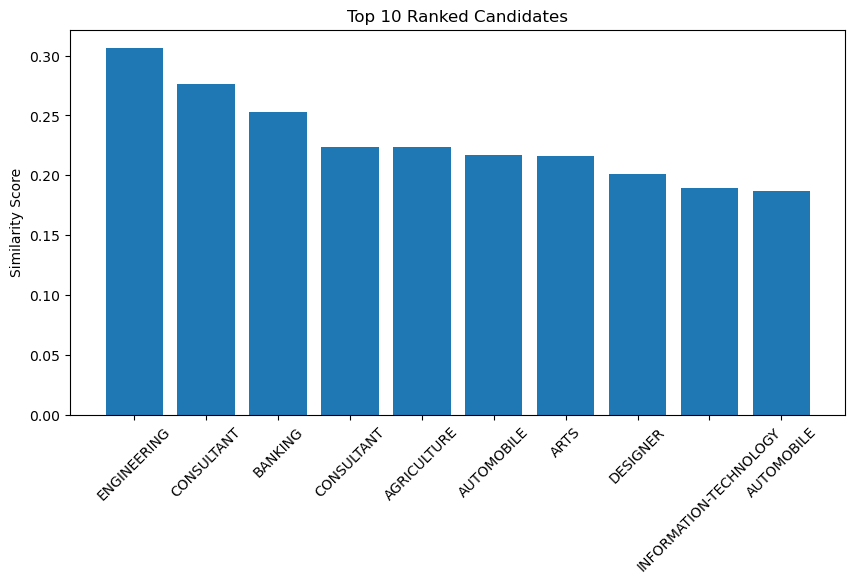

In [21]:
top10 = top_candidates.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top10)),
    top10['Similarity_Score']
)

plt.xticks(
    range(len(top10)),
    top10['Category'],
    rotation=45
)

plt.title("Top 10 Ranked Candidates")

plt.ylabel("Similarity Score")

plt.show()

In [22]:
skills = [
    "python",
    "machine learning",
    "sql",
    "data analysis",
    "pandas",
    "numpy"
]

best_resume = top_candidates.iloc[0]['clean_resume']

missing_skills = []

for skill in skills:
    if skill not in best_resume:
        missing_skills.append(skill)

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['numpy']


In [23]:
skills = [
    "python",
    "machine learning",
    "sql",
    "data analysis",
    "pandas",
    "numpy",
    "scikit learn"
]

best_resume = top_candidates.iloc[0]['clean_resume']

missing_skills = []

for skill in skills:
    if skill not in best_resume:
        missing_skills.append(skill)

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['numpy', 'scikit learn']
